In [42]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Tong so mau: 16,175


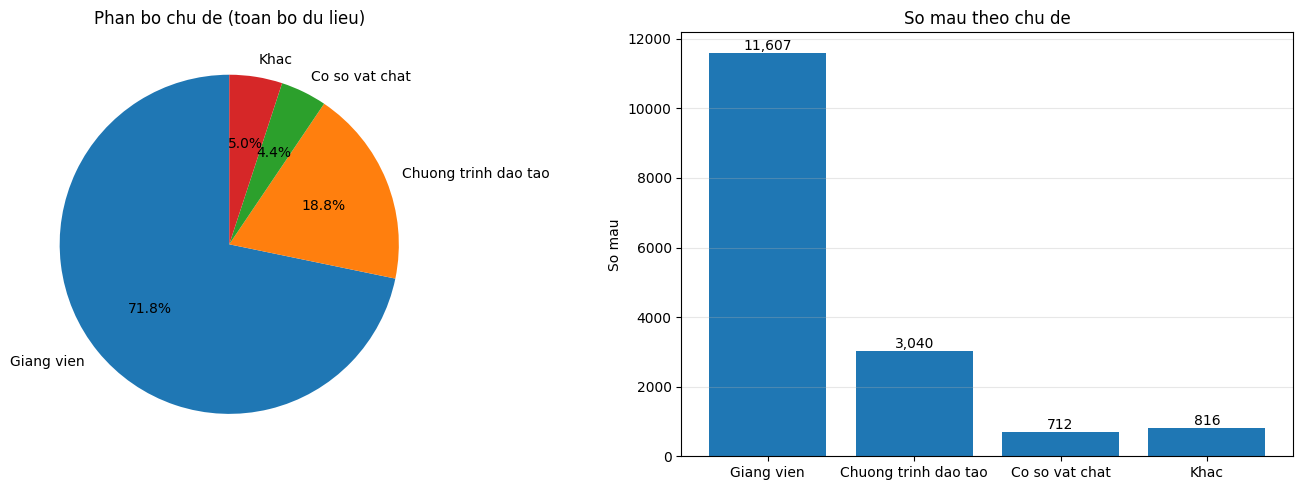

Bang dem sentiment x topic:


,Tieu cuc,Trung tinh,Tich cuc
Giang vien,4105,292,7210
Chuong trinh dao tao,2328,162,550
Co so vat chat,681,13,18
Khac,325,231,260


Ti le % sentiment ben trong tung topic:


,Tieu cuc,Trung tinh,Tich cuc
Giang vien,35.37,2.52,62.12
Chuong trinh dao tao,76.58,5.33,18.09
Co so vat chat,95.65,1.83,2.53
Khac,39.83,28.31,31.86


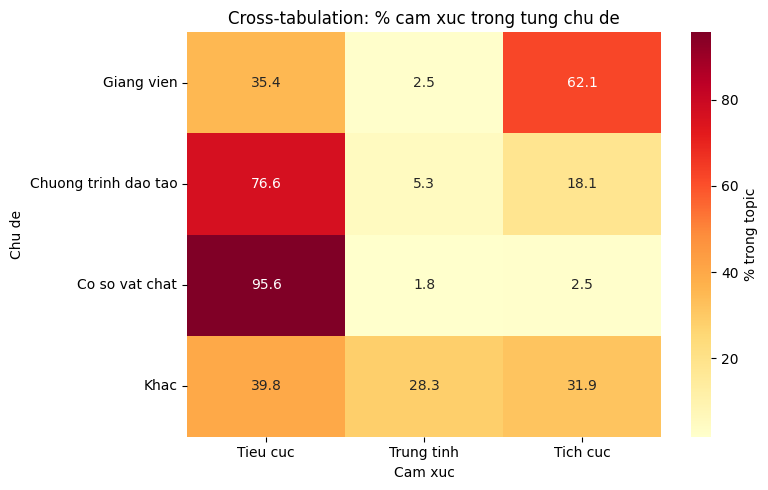

In [43]:
import os
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def load_data_with_topics(data_dir, split):
    split_dir = os.path.join(data_dir, split)
    with open(os.path.join(split_dir, 'sents.txt'), 'r', encoding='utf-8') as f:
        texts = [line.strip() for line in f.readlines()]
    with open(os.path.join(split_dir, 'sentiments.txt'), 'r', encoding='utf-8') as f:
        labels = [int(line.strip()) for line in f.readlines()]
    with open(os.path.join(split_dir, 'topics.txt'), 'r', encoding='utf-8') as f:
        topics = [int(line.strip()) for line in f.readlines()]
    return texts, labels, topics

topic_map = {0: 'Giang vien', 1: 'Chuong trinh dao tao', 2: 'Co so vat chat', 3: 'Khac'}
label_map = {0: 'Tieu cuc', 1: 'Trung tinh', 2: 'Tich cuc'}

base_dir_candidates = [
    '/content/drive/MyDrive/Student-Feedback-Sentiment-Analysis',
    '.',
]
data_dir = None
for c in base_dir_candidates:
    candidate = os.path.join(c, 'data', 'processed')
    if os.path.exists(candidate):
        data_dir = candidate
        break
if data_dir is None:
    raise FileNotFoundError('Khong tim thay data/processed')

all_rows = []
for split in ['train', 'validation', 'test']:
    _, labels, topics = load_data_with_topics(data_dir, split)
    all_rows.extend([{'split': split, 'label': y, 'topic': t} for y, t in zip(labels, topics)])

full_df = pd.DataFrame(all_rows)
print(f'Tong so mau: {len(full_df):,}')

# 1) Topic distribution
topic_counts = full_df['topic'].value_counts().sort_index()
topic_names = [topic_map[i] for i in topic_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].pie(topic_counts.values, labels=topic_names, autopct='%1.1f%%', startangle=90)
axes[0].set_title('Phan bo chu de (toan bo du lieu)')

bars = axes[1].bar(topic_names, topic_counts.values)
axes[1].set_title('So mau theo chu de')
axes[1].set_ylabel('So mau')
axes[1].grid(axis='y', alpha=0.3)
for b in bars:
    h = b.get_height()
    axes[1].text(b.get_x() + b.get_width()/2, h, f'{int(h):,}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

# 2) Cross-tab sentiment within each topic
crosstab_count = pd.crosstab(full_df['topic'], full_df['label'])
crosstab_pct = pd.crosstab(full_df['topic'], full_df['label'], normalize='index') * 100
crosstab_count.index = [topic_map[i] for i in crosstab_count.index]
crosstab_count.columns = [label_map[i] for i in crosstab_count.columns]
crosstab_pct.index = [topic_map[i] for i in crosstab_pct.index]
crosstab_pct.columns = [label_map[i] for i in crosstab_pct.columns]

print('Bang dem sentiment x topic:')
display(crosstab_count)
print('Ti le % sentiment ben trong tung topic:')
display(crosstab_pct.round(2))

plt.figure(figsize=(8, 5))
sns.heatmap(crosstab_pct, annot=True, fmt='.1f', cmap='YlOrRd', cbar_kws={'label': '% trong topic'})
plt.title('Cross-tabulation: % cam xuc trong tung chu de')
plt.ylabel('Chu de')
plt.xlabel('Cam xuc')
plt.tight_layout()
plt.show()

## Topic Analysis: Phan bo chu de va cam xuc vat cheo

Phan nay bo sung thong ke theo topic tren toan bo du lieu (train + validation + test):
- Bieu do tron/cot phan bo chu de
- Cross-tabulation ti le Tich cuc/Trung tinh/Tieu cuc ben trong tung chu de

# PhoBERT Baseline - Cross Entropy Loss

## Mô tả
Notebook này triển khai mô hình PhoBERT baseline cho phân tích cảm xúc sinh viên.

**Đặc điểm:**
- Sử dụng PhoBERT pre-trained (vinai/phobert-base)
- Loss function: CrossEntropyLoss (standard)
- Không sử dụng data augmentation
- Không sử dụng class weights

**Mục đích:** Làm baseline để so sánh với các phương pháp cải tiến.

## 1. Setup và Import Libraries

In [44]:
!pip install transformers torch scikit-learn matplotlib seaborn

In [45]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import random
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


In [46]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

## 2. Configuration

In [47]:
class Config:
    BASE_DIR = '/content/drive/MyDrive/Student-Feedback-Sentiment-Analysis'
    DATA_DIR = f'{BASE_DIR}/data/processed'
    # NEW: Hierarchical results directory structure
    # Format: results/{ModelType}/{baseline|improvements}/
    MODEL_TYPE = 'PhoBERT'
    EXPERIMENT_TYPE = 'baseline'  # Baseline has no timestamp
    RESULTS_DIR = f'{BASE_DIR}/results/{MODEL_TYPE}/{EXPERIMENT_TYPE}'

    MODEL_NAME = 'vinai/phobert-base'
    MAX_LENGTH = 256
    BATCH_SIZE = 16
    LEARNING_RATE = 2e-5
    NUM_EPOCHS = 10
    WARMUP_RATIO = 0.1
    WEIGHT_DECAY = 0.01
    EARLY_STOPPING_PATIENCE = 2
    NUM_CLASSES = 3
    LABEL_MAP = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Subdirectories for organized outputs
    MODELS_DIR = os.path.join(RESULTS_DIR, 'models')
    SUMMARIES_DIR = os.path.join(RESULTS_DIR, 'summaries')
    VISUALIZATIONS_DIR = os.path.join(RESULTS_DIR, 'visualizations')
    ARTIFACTS_DIR = os.path.join(RESULTS_DIR, 'artifacts')

config = Config()
# Create all subdirectories
for dir_path in [config.RESULTS_DIR, config.MODELS_DIR, config.SUMMARIES_DIR,
                 config.VISUALIZATIONS_DIR, config.ARTIFACTS_DIR]:
    os.makedirs(dir_path, exist_ok=True)

print(f'Results will be saved to: {config.RESULTS_DIR}')
print(f'Device: {config.DEVICE}')
print(f'Structure: models/, summaries/, visualizations/, artifacts/')

Results will be saved to: /content/drive/MyDrive/Student-Feedback-Sentiment-Analysis/results/PhoBERT/baseline
Device: cuda
Structure: models/, summaries/, visualizations/, artifacts/


## 3. Load Data

In [48]:
def load_data(data_dir, split):
    split_dir = os.path.join(data_dir, split)
    with open(os.path.join(split_dir, 'sents.txt'), 'r', encoding='utf-8') as f:
        texts = [line.strip() for line in f.readlines()]
    with open(os.path.join(split_dir, 'sentiments.txt'), 'r', encoding='utf-8') as f:
        labels = [int(line.strip()) for line in f.readlines()]
    print(f'{split}: {len(texts)} samples')
    return texts, labels

train_texts, train_labels = load_data(config.DATA_DIR, 'train')
val_texts, val_labels = load_data(config.DATA_DIR, 'validation')
test_texts, test_labels = load_data(config.DATA_DIR, 'test')

train: 11426 samples
validation: 1583 samples
test: 3166 samples


In [49]:
from collections import Counter

print('Label distribution:')
for split_name, labels in [('Train', train_labels), ('Val', val_labels), ('Test', test_labels)]:
    counter = Counter(labels)
    print(f'{split_name}:')
    for label, count in sorted(counter.items()):
        print(f'  {config.LABEL_MAP[label]}: {count} ({count/len(labels)*100:.1f}%)')

Label distribution:
Train:
  Negative: 5325 (46.6%)
  Neutral: 458 (4.0%)
  Positive: 5643 (49.4%)
Val:
  Negative: 705 (44.5%)
  Neutral: 73 (4.6%)
  Positive: 805 (50.9%)
Test:
  Negative: 1409 (44.5%)
  Neutral: 167 (5.3%)
  Positive: 1590 (50.2%)


## 4. Dataset và DataLoader

In [50]:
tokenizer = AutoTokenizer.from_pretrained(config.MODEL_NAME)
print(f'Tokenizer loaded: {config.MODEL_NAME}')

Tokenizer loaded: vinai/phobert-base


In [51]:
class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'label': torch.tensor(label, dtype=torch.long)
        }

In [52]:
train_dataset = SentimentDataset(train_texts, train_labels, tokenizer, config.MAX_LENGTH)
val_dataset = SentimentDataset(val_texts, val_labels, tokenizer, config.MAX_LENGTH)
test_dataset = SentimentDataset(test_texts, test_labels, tokenizer, config.MAX_LENGTH)

train_loader = DataLoader(train_dataset, batch_size=config.BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=config.BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=config.BATCH_SIZE, shuffle=False)

print(f'Train batches: {len(train_loader)}')
print(f'Val batches: {len(val_loader)}')
print(f'Test batches: {len(test_loader)}')

Train batches: 715
Val batches: 99
Test batches: 198


## 5. Model Definition

In [53]:
class PhoBERTClassifier(nn.Module):
    def __init__(self, model_name, num_classes, dropout=0.1):
        super(PhoBERTClassifier, self).__init__()
        self.phobert = AutoModel.from_pretrained(model_name)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(self.phobert.config.hidden_size, num_classes)

    def forward(self, input_ids, attention_mask):
        outputs = self.phobert(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.last_hidden_state[:, 0, :]
        pooled_output = self.dropout(pooled_output)
        logits = self.classifier(pooled_output)
        return logits

In [54]:
model = PhoBERTClassifier(model_name=config.MODEL_NAME, num_classes=config.NUM_CLASSES)
model = model.to(config.DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters: {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.decoder.weight          | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 
lm_head.layer_norm.weight       | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 
lm_head.dense.weight            | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.bias                    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total parameters: 135,000,579
Trainable parameters: 135,000,579


## 6. Training Setup - CrossEntropyLoss (Baseline)

In [55]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(model.parameters(), lr=config.LEARNING_RATE, weight_decay=config.WEIGHT_DECAY)

total_steps = len(train_loader) * config.NUM_EPOCHS
warmup_steps = int(total_steps * config.WARMUP_RATIO)
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps)

print('Loss function: CrossEntropyLoss (standard)')
print(f'Total training steps: {total_steps}')
print(f'Warmup steps: {warmup_steps}')

Loss function: CrossEntropyLoss (standard)
Total training steps: 7150
Warmup steps: 715


## 7. Training Functions

In [56]:
def train_epoch(model, dataloader, criterion, optimizer, scheduler, device):
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []
    progress_bar = tqdm(dataloader, desc='Training')
    for batch in progress_bar:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)
        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        progress_bar.set_postfix({'loss': f'{loss.item():.4f}'})
    avg_loss = total_loss / len(dataloader)
    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted')
    return avg_loss, accuracy, f1

In [57]:
def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for batch in tqdm(dataloader, desc='Evaluating'):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)
            outputs = model(input_ids, attention_mask)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    avg_loss = total_loss / len(dataloader)
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='weighted')
    return avg_loss, accuracy, precision, recall, f1, all_preds, all_labels


## 8. Training Loop

In [58]:
history = {'train_loss': [], 'train_acc': [], 'train_f1': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}
best_val_f1 = 0
patience_counter = 0

if 'config' not in globals():
    if 'Config' not in globals():
        raise NameError('`config` is not defined. Run the Configuration cell first.')
    config = Config()
    for dir_path in [config.RESULTS_DIR, config.MODELS_DIR, config.SUMMARIES_DIR,
                     config.VISUALIZATIONS_DIR, config.ARTIFACTS_DIR]:
        os.makedirs(dir_path, exist_ok=True)
    print('`config` was missing, recreated from Config().')

required_objects = ['model', 'train_loader', 'val_loader', 'criterion', 'optimizer', 'scheduler', 'train_epoch', 'evaluate']
missing_objects = [name for name in required_objects if name not in globals()]
if missing_objects:
    raise NameError(f'Missing required objects for training: {missing_objects}. Run the previous setup cells first.')

print('='*60)
print('Starting Training - PhoBERT Baseline (CrossEntropyLoss)')
print('='*60)

for epoch in range(config.NUM_EPOCHS):
    print(f'Epoch {epoch + 1}/{config.NUM_EPOCHS}')
    train_loss, train_acc, train_f1 = train_epoch(model, train_loader, criterion, optimizer, scheduler, config.DEVICE)
    val_loss, val_acc, val_precision, val_recall, val_f1, _, _ = evaluate(model, val_loader, criterion, config.DEVICE)
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['train_f1'].append(train_f1)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)
    print(f'Train - Loss: {train_loss:.4f}, Acc: {train_acc:.4f}, F1: {train_f1:.4f}')
    print(f'Val   - Loss: {val_loss:.4f}, Acc: {val_acc:.4f}, F1: {val_f1:.4f}')
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        patience_counter = 0
        # NEW: Save to models directory
        torch.save(model.state_dict(), os.path.join(config.MODELS_DIR, 'phobert_model.pt'))
        print(f'New best model saved! Val F1: {val_f1:.4f}')
    else:
        patience_counter += 1
        print(f'No improvement. Patience: {patience_counter}/{config.EARLY_STOPPING_PATIENCE}')
        if patience_counter >= config.EARLY_STOPPING_PATIENCE:
            print(f'Early stopping triggered at epoch {epoch + 1}')
            break

print('='*60)
print(f'Training completed! Best Val F1: {best_val_f1:.4f}')
print('='*60)

Starting Training - PhoBERT Baseline (CrossEntropyLoss)
Epoch 1/10


Evaluating: 100%|██████████| 99/99 [00:20<00:00,  4.88it/s]


Train - Loss: 0.4806, Acc: 0.8075, F1: 0.7987
Val   - Loss: 0.2268, Acc: 0.9318, F1: 0.9261
New best model saved! Val F1: 0.9261
Epoch 2/10


Evaluating: 100%|██████████| 99/99 [00:20<00:00,  4.90it/s]


Train - Loss: 0.2237, Acc: 0.9330, F1: 0.9294
Val   - Loss: 0.3102, Acc: 0.9356, F1: 0.9245
No improvement. Patience: 1/2
Epoch 3/10


...

Train - Loss: 0.0915, Acc: 0.9768, F1: 0.9766
Val   - Loss: 0.2713, Acc: 0.9469, F1: 0.9445
New best model saved! Val F1: 0.9445
Epoch 6/10


Evaluating: 100%|██████████| 99/99 [00:20<00:00,  4.91it/s]


Train - Loss: 0.0652, Acc: 0.9850, F1: 0.9849
Val   - Loss: 0.3236, Acc: 0.9431, F1: 0.9413
No improvement. Patience: 1/2
Epoch 7/10


Evaluating: 100%|██████████| 99/99 [00:20<00:00,  4.91it/s]


Train - Loss: 0.0506, Acc: 0.9884, F1: 0.9884
Val   - Loss: 0.3160, Acc: 0.9457, F1: 0.9432
No improvement. Patience: 2/2
Early stopping triggered at epoch 7
Training completed! Best Val F1: 0.9445


## 9. Training Visualization

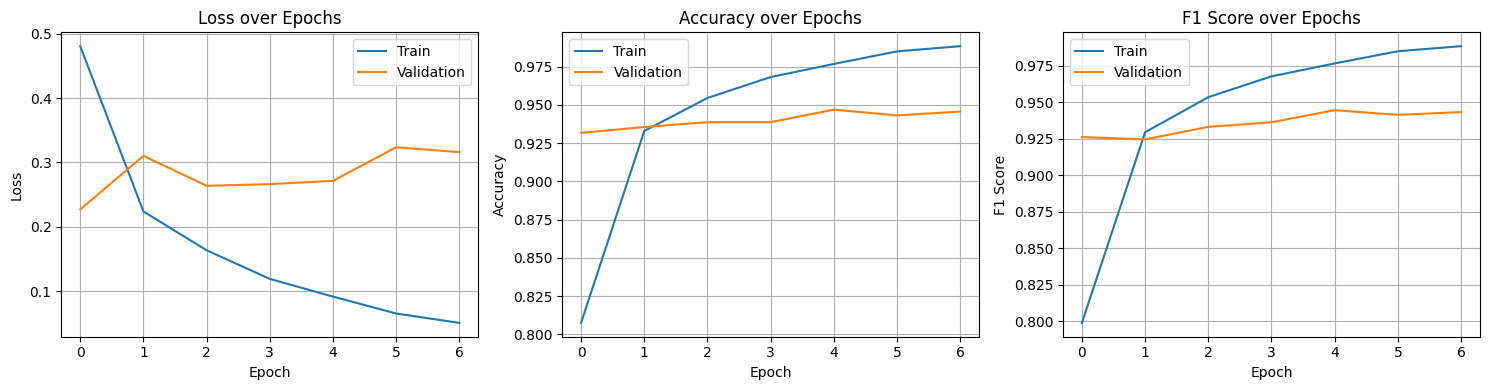

In [59]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(history['train_loss'], label='Train')
axes[0].plot(history['val_loss'], label='Validation')
axes[0].set_title('Loss over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)
axes[1].plot(history['train_acc'], label='Train')
axes[1].plot(history['val_acc'], label='Validation')
axes[1].set_title('Accuracy over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)
axes[2].plot(history['train_f1'], label='Train')
axes[2].plot(history['val_f1'], label='Validation')
axes[2].set_title('F1 Score over Epochs')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('F1 Score')
axes[2].legend()
axes[2].grid(True)
plt.tight_layout()
# NEW: Save to visualizations directory
plt.savefig(os.path.join(config.VISUALIZATIONS_DIR, 'training_history.png'), dpi=150)
plt.show()

## 10. Evaluation on Test Set

In [60]:
# NEW: Load from models directory
model.load_state_dict(torch.load(os.path.join(config.MODELS_DIR, 'phobert_model.pt')))
print('Best model loaded for evaluation')

test_loss, test_acc, test_precision, test_recall, test_f1, test_preds, test_labels = evaluate(model, test_loader, criterion, config.DEVICE)

print('='*60)
print('TEST SET RESULTS - PhoBERT Baseline (CrossEntropyLoss)')
print('='*60)
print(f'Loss: {test_loss:.4f}')
print(f'Accuracy: {test_acc:.4f}')
print(f'Precision (weighted): {test_precision:.4f}')
print(f'Recall (weighted): {test_recall:.4f}')
print(f'F1 Score (weighted): {test_f1:.4f}')


Best model loaded for evaluation


Evaluating: 100%|██████████| 198/198 [00:40<00:00,  4.89it/s]


TEST SET RESULTS - PhoBERT Baseline (CrossEntropyLoss)
Loss: 0.3291
Accuracy: 0.9321
Precision (weighted): 0.9285
Recall (weighted): 0.9321
F1 Score (weighted): 0.9291


In [61]:
print('Classification Report:')
target_names = [config.LABEL_MAP[i] for i in range(config.NUM_CLASSES)]
print(classification_report(test_labels, test_preds, target_names=target_names, digits=4))

Classification Report:
              precision    recall  f1-score   support

    Negative     0.9279    0.9681    0.9476      1409
     Neutral     0.6983    0.4850    0.5724       167
    Positive     0.9532    0.9472    0.9502      1590

    accuracy                         0.9321      3166
   macro avg     0.8598    0.8001    0.8234      3166
weighted avg     0.9285    0.9321    0.9291      3166



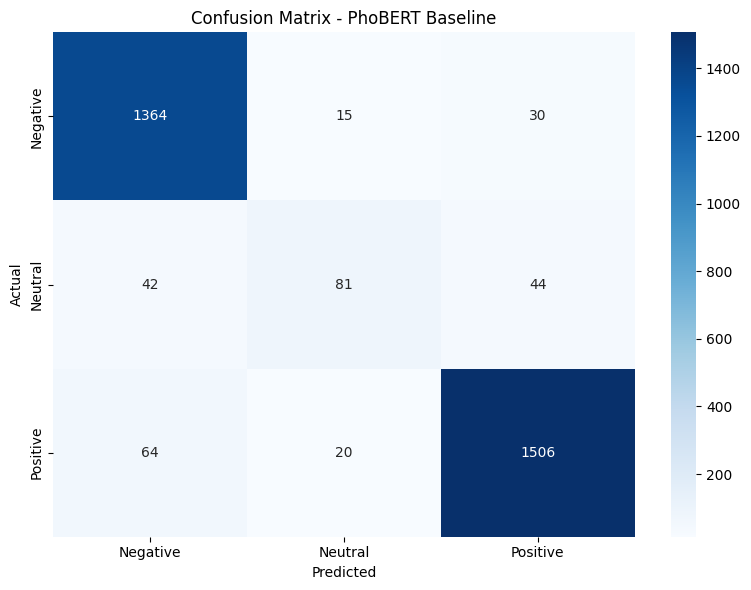

In [62]:
cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix - PhoBERT Baseline')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
# NEW: Save to visualizations directory
plt.savefig(os.path.join(config.VISUALIZATIONS_DIR, 'confusion_matrix.png'), dpi=150)
plt.show()

## Topic-wise Sentiment Analysis

Phan tich ket qua sentiment analysis theo tung chu de tren tap test.

In [63]:
from sklearn.metrics import precision_recall_fscore_support

TOPIC_MAP = {0: 'Giang vien', 1: 'Chuong trinh dao tao', 2: 'Co so vat chat', 3: 'Khac'}

with open(os.path.join(config.DATA_DIR, 'test', 'topics.txt'), 'r', encoding='utf-8') as f:
    test_topics = [int(line.strip()) for line in f.readlines()]

topic_df = pd.DataFrame({
    'topic': test_topics,
    'y_true': list(map(int, test_labels)),
    'y_pred': list(map(int, test_preds)),
})

topic_rows = []
for topic_id in sorted(topic_df['topic'].unique()):
    sub = topic_df[topic_df['topic'] == topic_id]
    p, r, f1, support = precision_recall_fscore_support(
        sub['y_true'], sub['y_pred'], labels=[0, 1, 2], zero_division=0
    )
    topic_rows.append({
        'topic_id': int(topic_id),
        'topic_name': TOPIC_MAP.get(int(topic_id), str(topic_id)),
        'samples': int(len(sub)),
        'accuracy': float(accuracy_score(sub['y_true'], sub['y_pred'])),
        'f1_macro': float(f1_score(sub['y_true'], sub['y_pred'], average='macro', zero_division=0)),
        'f1_weighted': float(f1_score(sub['y_true'], sub['y_pred'], average='weighted', zero_division=0)),
        'f1_negative': float(f1[0]),
        'f1_neutral': float(f1[1]),
        'f1_positive': float(f1[2]),
    })

topic_metrics_df = pd.DataFrame(topic_rows).sort_values('topic_id')
print('=== Topic-wise Metrics (Test Set) ===')
display(topic_metrics_df)

for topic_id in sorted(topic_df['topic'].unique()):
    sub = topic_df[topic_df['topic'] == topic_id]
    print(f"\n--- Topic {topic_id} ({TOPIC_MAP.get(int(topic_id), str(topic_id))}) - {len(sub)} samples ---")
    print(classification_report(sub['y_true'], sub['y_pred'], target_names=list(config.LABEL_MAP.values()), zero_division=0))

topic_metrics_df.to_csv(os.path.join(config.SUMMARIES_DIR, 'topic_metrics.csv'), index=False)
topic_df.to_csv(os.path.join(config.SUMMARIES_DIR, 'topic_predictions_test.csv'), index=False)
print(f'\nSaved: topic_metrics.csv, topic_predictions_test.csv')

=== Topic-wise Metrics (Test Set) ===


,topic_id,topic_name,samples,accuracy,f1_macro,f1_weighted,f1_negative,f1_neutral,f1_positive
0,0,Giang vien,2290,0.944978,0.814944,0.942789,0.946329,0.536585,0.961918
1,1,Chuong trinh dao tao,572,0.905594,0.778297,0.899224,0.952719,0.526316,0.855856
2,2,Co so vat chat,145,0.979310,0.809533,0.980498,0.992701,0.666667,0.769231
3,3,Khac,159,0.798742,0.785244,0.794988,0.840580,0.666667,0.848485



--- Topic 0 (Giang vien) - 2290 samples ---
              precision    recall  f1-score   support

    Negative       0.92      0.97      0.95       791
     Neutral       0.67      0.45      0.54        74
    Positive       0.97      0.96      0.96      1425

    accuracy                           0.94      2290
   macro avg       0.85      0.79      0.81      2290
weighted avg       0.94      0.94      0.94      2290


--- Topic 1 (Chuong trinh dao tao) - 572 samples ---
              precision    recall  f1-score   support

    Negative       0.94      0.97      0.95       416
     Neutral       0.69      0.43      0.53        47
    Positive       0.84      0.87      0.86       109

    accuracy                           0.91       572
   macro avg       0.82      0.76      0.78       572
weighted avg       0.90      0.91      0.90       572


--- Topic 2 (Co so vat chat) - 145 samples ---
              precision    recall  f1-score   support

    Negative       1.00      0.99   

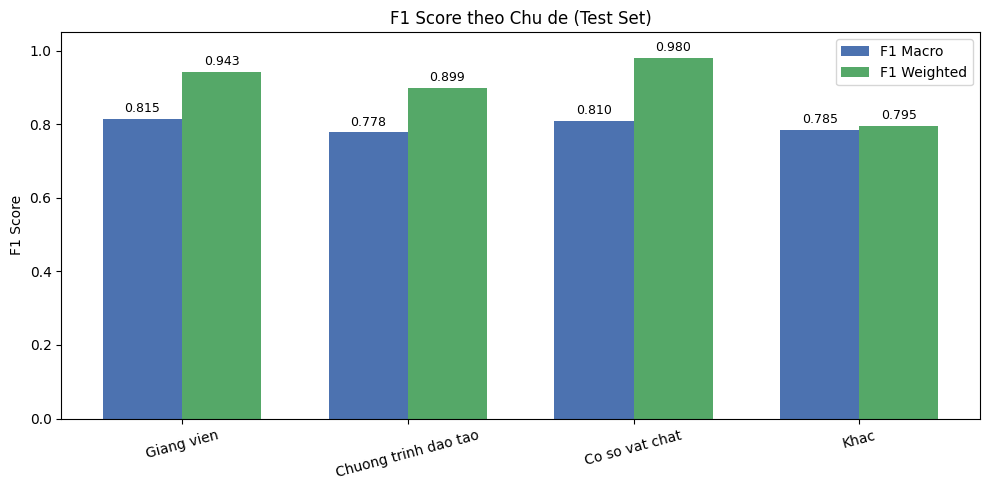

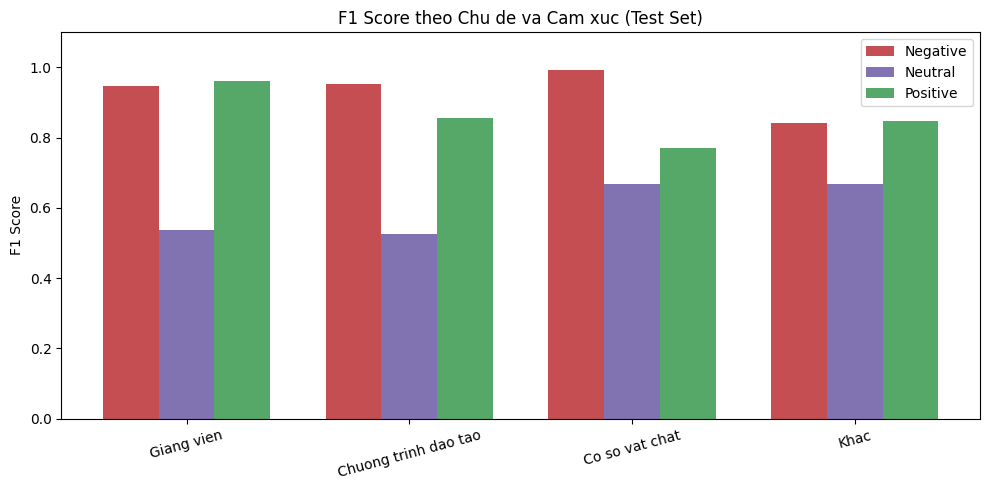

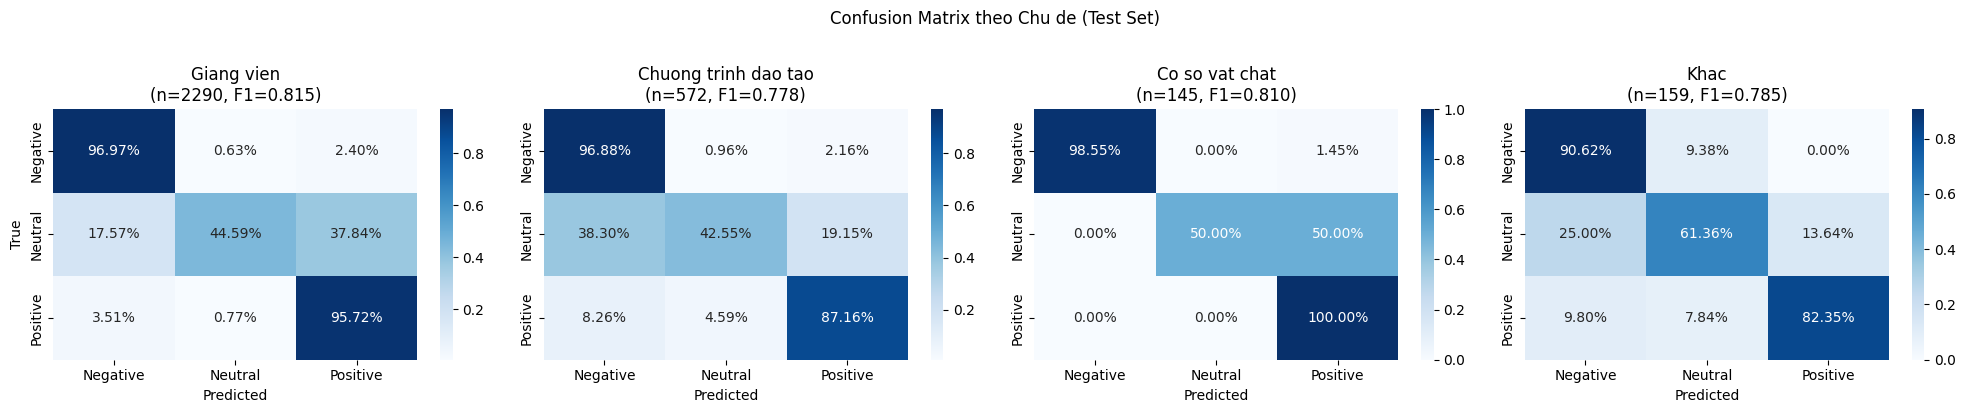

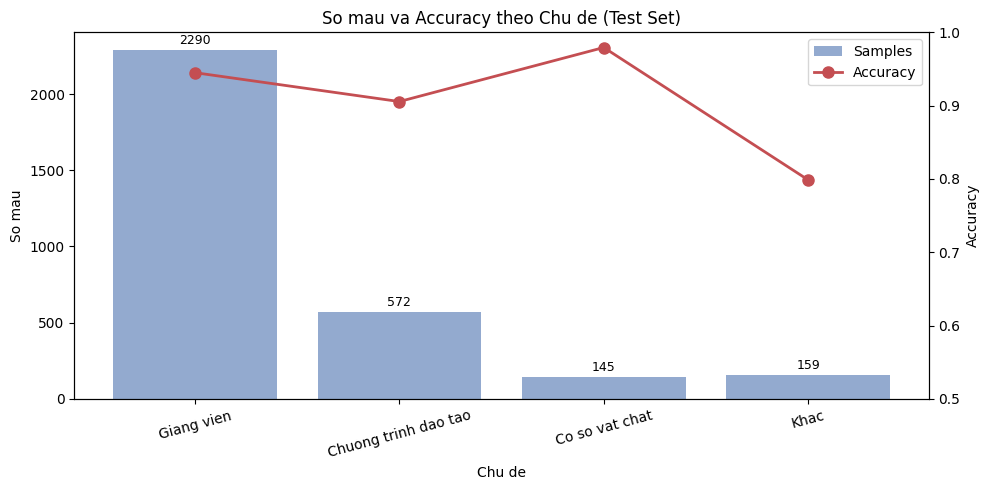

Da luu tat ca bieu do topic-wise vao: /content/drive/MyDrive/Student-Feedback-Sentiment-Analysis/results/PhoBERT/baseline/visualizations


In [64]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(topic_metrics_df))
width = 0.35
bars1 = ax.bar(x - width/2, topic_metrics_df['f1_macro'], width, label='F1 Macro', color='#4C72B0')
bars2 = ax.bar(x + width/2, topic_metrics_df['f1_weighted'], width, label='F1 Weighted', color='#55A868')
ax.set_xticks(x)
ax.set_xticklabels(topic_metrics_df['topic_name'], rotation=15)
ax.set_ylabel('F1 Score')
ax.set_ylim(0, 1.05)
ax.set_title('F1 Score theo Chu de (Test Set)')
ax.legend()
for b in bars1:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01, f'{b.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for b in bars2:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01, f'{b.get_height():.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(config.VISUALIZATIONS_DIR, 'topic_f1_scores.png'), dpi=150, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(topic_metrics_df))
width = 0.25
ax.bar(x - width, topic_metrics_df['f1_negative'], width, label='Negative', color='#C44E52')
ax.bar(x, topic_metrics_df['f1_neutral'], width, label='Neutral', color='#8172B2')
ax.bar(x + width, topic_metrics_df['f1_positive'], width, label='Positive', color='#55A868')
ax.set_xticks(x)
ax.set_xticklabels(topic_metrics_df['topic_name'], rotation=15)
ax.set_ylabel('F1 Score')
ax.set_ylim(0, 1.1)
ax.set_title('F1 Score theo Chu de va Cam xuc (Test Set)')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(config.VISUALIZATIONS_DIR, 'topic_sentiment_f1.png'), dpi=150, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, len(topic_metrics_df), figsize=(5 * len(topic_metrics_df), 4))
label_names = list(config.LABEL_MAP.values())
for i, row in topic_metrics_df.iterrows():
    sub = topic_df[topic_df['topic'] == row['topic_id']]
    cm_topic = confusion_matrix(sub['y_true'], sub['y_pred'], labels=[0, 1, 2])
    cm_topic_norm = cm_topic.astype(float) / cm_topic.sum(axis=1, keepdims=True).clip(min=1)
    sns.heatmap(cm_topic_norm, annot=True, fmt='.2%', cmap='Blues',
                xticklabels=label_names, yticklabels=label_names, ax=axes[i])
    axes[i].set_title(f"{row['topic_name']}\n(n={row['samples']}, F1={row['f1_macro']:.3f})")
    if i == 0:
        axes[i].set_ylabel('True')
    axes[i].set_xlabel('Predicted')
plt.suptitle('Confusion Matrix theo Chu de (Test Set)', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(config.VISUALIZATIONS_DIR, 'topic_confusion_matrices.png'), dpi=150, bbox_inches='tight')
plt.show()

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()
bars = ax1.bar(x, topic_metrics_df['samples'], color='#4C72B0', alpha=0.6, label='Samples')
ax1.set_ylabel('So mau')
ax1.set_xlabel('Chu de')
ax1.set_xticks(x)
ax1.set_xticklabels(topic_metrics_df['topic_name'], rotation=15)
ax2.plot(x, topic_metrics_df['accuracy'], 'o-', color='#C44E52', linewidth=2, markersize=8, label='Accuracy')
ax2.set_ylabel('Accuracy')
ax2.set_ylim(0.5, 1.0)
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc='upper right')
ax1.set_title('So mau va Accuracy theo Chu de (Test Set)')
for b in bars:
    ax1.text(b.get_x() + b.get_width()/2, b.get_height() + 20, f'{int(b.get_height())}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(config.VISUALIZATIONS_DIR, 'topic_samples_accuracy.png'), dpi=150, bbox_inches='tight')
plt.show()

print('Da luu tat ca bieu do topic-wise vao:', config.VISUALIZATIONS_DIR)

## 11. Save Results

In [65]:
import pandas as pd

summary = {
    'Model': 'PhoBERT Baseline',
    'Loss Function': 'CrossEntropyLoss',
    'Data Augmentation': 'No',
    'Class Weights': 'No',
    'Epochs Trained': len(history['train_loss']),
    'Best Val F1': best_val_f1,
    'Test Accuracy': test_acc,
    'Test Precision (weighted)': test_precision,
    'Test Recall (weighted)': test_recall,
    'Test F1 (weighted)': test_f1,
    'Test Loss': test_loss
}

summary_df = pd.DataFrame([summary])
summary_df.to_csv(os.path.join(config.SUMMARIES_DIR, 'summary.csv'), index=False)

print('='*60)
print('SAVING RESULTS')
print('='*60)
print('Results Summary:')
for key, value in summary.items():
    if isinstance(value, float):
        print(f'{key}: {value:.4f}')
    else:
        print(f'{key}: {value}')

print(f'\nAll results saved to: {config.RESULTS_DIR}')
print('  - models/phobert_model.pt')
print('  - summaries/summary.csv')
print('  - visualizations/training_history.png, confusion_matrix.png')


SAVING RESULTS
Results Summary:
Model: PhoBERT Baseline
Loss Function: CrossEntropyLoss
Data Augmentation: No
Class Weights: No
Epochs Trained: 7
Best Val F1: 0.9445
Test Accuracy: 0.9321
Test Precision (weighted): 0.9285
Test Recall (weighted): 0.9321
Test F1 (weighted): 0.9291
Test Loss: 0.3291

All results saved to: /content/drive/MyDrive/Student-Feedback-Sentiment-Analysis/results/PhoBERT/baseline
  - models/phobert_model.pt
  - summaries/summary.csv
  - visualizations/training_history.png, confusion_matrix.png


## 12. Summary

### PhoBERT Baseline Model

**Configuration:**
- Model: vinai/phobert-base
- Loss: CrossEntropyLoss (standard)
- No data augmentation
- No class weights
- Epochs: 10 (with early stopping)

**Purpose:**
This baseline model serves as a reference point for comparing with enhanced versions like:
- PhoBERT + Focal Loss
- PhoBERT + Data Augmentation
- PhoBERT + Class Weights